In [2]:
# ==========================================
# LAB 5: LSTM TEXT + SEQ2SEQ (FULL)
# ==========================================


In [3]:

# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


In [4]:

# ------------------------------------------
# 2. Load Dataset (IMDB)
# ------------------------------------------
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("\n===== DATASET INFO =====")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))



===== DATASET INFO =====
Training samples: 25000
Testing samples : 25000


In [5]:

# ------------------------------------------
# 3. DATASET ANALYSIS
# ------------------------------------------
train_lengths = [len(x) for x in X_train]

print("\n===== DATA ANALYSIS =====")
print("Average review length:", int(np.mean(train_lengths)))
print("Max review length    :", max(train_lengths))
print("Min review length    :", min(train_lengths))



===== DATA ANALYSIS =====
Average review length: 238
Max review length    : 2494
Min review length    : 11


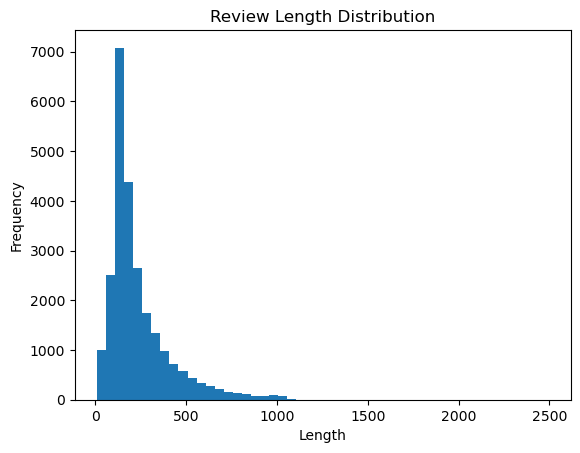

In [6]:

# Plot review length distribution
plt.figure()
plt.hist(train_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()



Class Distribution:
Positive: 12500
Negative: 12500


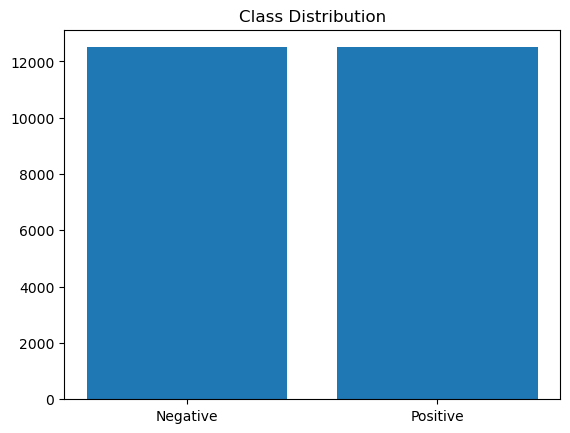

In [7]:

# Class distribution
positive = sum(y_train)
negative = len(y_train) - positive

print("\nClass Distribution:")
print("Positive:", positive)
print("Negative:", negative)

plt.figure()
plt.bar(["Negative", "Positive"], [negative, positive])
plt.title("Class Distribution")
plt.show()


In [8]:

# ------------------------------------------
# 4. Preprocessing
# ------------------------------------------
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("\nData Preprocessed")



Data Preprocessed


In [9]:

# ------------------------------------------
# 5. Build LSTM Model
# ------------------------------------------
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.summary()


c:\Users\mishr\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:

# ------------------------------------------
# 6. Compile
# ------------------------------------------
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [11]:

# ------------------------------------------
# 7. Train Model
# ------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

start = time.time()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

end = time.time()

training_time = end - start


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.7969 - loss: 0.4364 - val_accuracy: 0.8262 - val_loss: 0.4060
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 222ms/step - accuracy: 0.8963 - loss: 0.2625 - val_accuracy: 0.8570 - val_loss: 0.3313
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 246ms/step - accuracy: 0.9281 - loss: 0.1917 - val_accuracy: 0.8756 - val_loss: 0.3178
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.9463 - loss: 0.1483 - val_accuracy: 0.8580 - val_loss: 0.4397
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 246ms/step - accuracy: 0.9606 - loss: 0.1100 - val_accuracy: 0.8588 - val_loss: 0.4259


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,421 (15.21 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,948 (10.14 MB)

In [12]:

# ------------------------------------------
# 8. Evaluate Model
# ------------------------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("\n===== FINAL RESULT =====")
print("Test Accuracy :", accuracy)
print("Test Loss     :", loss)
print("Training Time :", training_time, "sec")


782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8647 - loss: 0.3372

===== FINAL RESULT =====
Test Accuracy : 0.8647199869155884
Test Loss     : 0.3372029960155487
Training Time : 383.55103945732117 sec


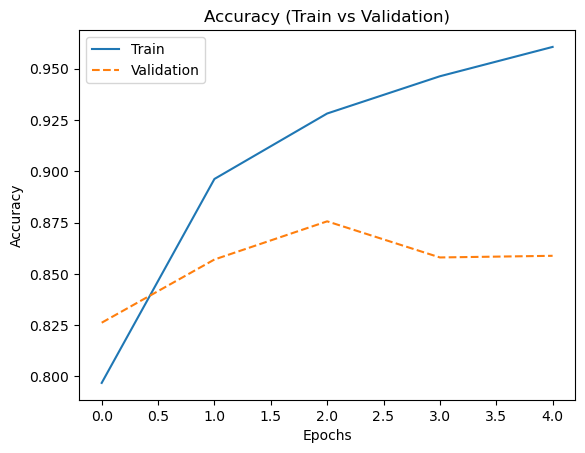

In [13]:

# ------------------------------------------
# 9. Plot Accuracy
# ------------------------------------------
plt.figure()

plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], linestyle='--', label="Validation")

plt.title("Accuracy (Train vs Validation)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


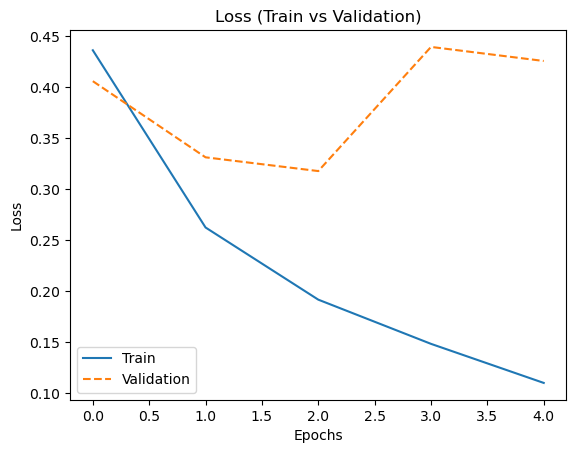

In [14]:

# ------------------------------------------
# 10. Plot Loss
# ------------------------------------------
plt.figure()

plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], linestyle='--', label="Validation")

plt.title("Loss (Train vs Validation)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [15]:

# ==========================================
# PART B: SEQ2SEQ MODEL
# ==========================================

print("\n===== SEQ2SEQ DEMO =====")

# Dummy sequence dataset
X_seq = np.array([
    [1,2,3],
    [2,3,4],
    [3,4,5]
])

y_seq = np.array([
    [2,3,4],
    [3,4,5],
    [4,5,6]
])

# reshape
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))
y_seq = y_seq.reshape((y_seq.shape[0], y_seq.shape[1], 1))

# Encoder
encoder_inputs = Input(shape=(3,1))
encoder_lstm = LSTM(64, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(3,1))
decoder_lstm = LSTM(64, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

decoder_dense = Dense(1)
decoder_outputs = decoder_dense(decoder_outputs)

# Model
seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

seq_model.compile(optimizer='adam', loss='mse')

seq_model.summary()



===== SEQ2SEQ DEMO =====


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 3, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 64),      │     16,896 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 3, 64),   │     16,896 │ input_layer_2[0]… │
│                     │ (None, 64),       │            │ lstm_1[0][1],     │
│                     │ (None, 64)]       │            │ lstm_1[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3, 1)      │         65 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,857 (132.25 KB)

 Trainable params: 33,857 (132.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:

# Train Seq2Seq
seq_model.fit([X_seq, X_seq], y_seq, epochs=100, verbose=0)

# Predict
pred = seq_model.predict([X_seq, X_seq])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


In [17]:

print("\nSeq2Seq Prediction:")
print(pred.round())


Seq2Seq Prediction:
[[[2.]
  [3.]
  [4.]]

 [[3.]
  [4.]
  [5.]]

 [[4.]
  [5.]
  [6.]]]
